In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg/biking/v_biking_05/v_biking_05_05.mpg
/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg/biking/v_biking_05/v_biking_05_04.mpg
/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg/biking/v_biking_05/v_biking_05_08.mpg
/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg/biking/v_biking_05/v_biking_05_01.mpg
/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg/biking/v_biking_05/v_biking_05_02.mpg
/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg/biking/v_biking_05/v_biking_05_03.mpg
/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg/biking/v_biking_05/v_biking_05_07.mpg
/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg/biking/v_biking_05/v_biking_05_09.mpg
/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg/biking/v_biking_05/v_

In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


In [5]:
import os

dataset_path = "/kaggle/input/realistic-action-recognition-ucf50-dataset/UCF11_updated_mpg"

# Check what’s inside
print("Number of action classes:", len(os.listdir(dataset_path)))
print("Example classes:", os.listdir(dataset_path)[:10])


Number of action classes: 11
Example classes: ['biking', 'trampoline_jumping', 'swing', 'walking', 'golf_swing', 'soccer_juggling', 'tennis_swing', 'volleyball_spiking', 'basketball', 'horse_riding']


In [6]:
IMG_SIZE = 112
SEQ_LEN = 20  # number of frames per video

def load_video_frames(video_path, max_frames=SEQ_LEN):
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total_frames // max_frames)

    for i in range(0, total_frames, step):
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frames.append(frame)
        if len(frames) == max_frames:
            break
    cap.release()
    return np.array(frames)


In [7]:
base_cnn = VGG16(weights="imagenet", include_top=False, pooling="avg")
cnn_model = Model(inputs=base_cnn.input, outputs=base_cnn.output)

def extract_features(frames):
    frames = frames / 255.0
    features = cnn_model.predict(frames, verbose=0)
    return features


I0000 00:00:1756380187.666336      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756380187.667075      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
classes = os.listdir(dataset_path)
class_to_idx = {cls: i for i, cls in enumerate(classes)}

X, y = [], []

for cls in classes[:10]:  # take 10 classes only (can expand later)
    class_folder = os.path.join(dataset_path, cls)
    subfolders = os.listdir(class_folder)
    
    for subfolder in subfolders[:5]:  # 5 videos per class
        sub_path = os.path.join(class_folder, subfolder)
        for video in os.listdir(sub_path):
            video_path = os.path.join(sub_path, video)
            frames = load_video_frames(video_path)
            if len(frames) == SEQ_LEN:
                features = extract_features(frames)
                X.append(features)
                y.append(class_to_idx[cls])

X = np.array(X)   # shape: (num_videos, SEQ_LEN, feature_dim)
y = to_categorical(y, num_classes=len(classes))


I0000 00:00:1756380190.878287     102 service.cc:148] XLA service 0x79183c0273d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756380190.879720     102 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756380190.879743     102 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756380191.055967     102 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756380194.413098     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [9]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
model = Sequential([
    LSTM(256, return_sequences=False, input_shape=(SEQ_LEN, X.shape[2])),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 821,771 (3.13 MB)

 Trainable params: 821,771 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
loss, acc = model.evaluate(test_X, test_y)
print(f"Test Accuracy: {acc:.2f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.0676 - loss: 2.4627
Test Accuracy: 0.07


In [12]:
for cls in classes[:10]:         # 10 classes only
    subfolders = os.listdir(os.path.join(dataset_path, cls))
    for subfolder in subfolders[:20]:   # up to 20 videos per class
        ...


In [13]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_X, train_y,
                    validation_data=(test_X, test_y),
                    epochs=30, batch_size=8,
                    callbacks=[early_stop])


Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.1186 - loss: 2.4803 - val_accuracy: 0.2632 - val_loss: 2.2265
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1552 - loss: 2.2409 - val_accuracy: 0.4912 - val_loss: 1.9309
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3527 - loss: 1.8993 - val_accuracy: 0.4561 - val_loss: 1.6303
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3585 - loss: 1.6940 - val_accuracy: 0.6316 - val_loss: 1.2386
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6632 - loss: 1.1409 - val_accuracy: 0.5088 - val_loss: 1.2868
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6615 - loss: 1.0975 - val_accuracy: 0.4737 - val_loss: 1.7194
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6474 - loss: 1.1874 - val_accuracy: 0.7544 - val_loss: 0.8228
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7402 - loss: 0.7257 - val_accuracy: 0.6842 - val_los

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-Head Attention
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    # Feed Forward
    y = layers.Dense(ff_dim, activation="relu")(x)
    y = layers.Dense(inputs.shape[-1])(y)
    y = layers.Dropout(dropout)(y)
    return layers.LayerNormalization(epsilon=1e-6)(x + y)

# Transformer-based classifier
def build_transformer(seq_len, feature_dim, num_classes):
    inputs = layers.Input(shape=(seq_len, feature_dim))
    
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=256, dropout=0.3)
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=256, dropout=0.3)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model


In [15]:
num_classes = y.shape[1]
model = build_transformer(SEQ_LEN, X.shape[2], num_classes)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(train_X, train_y,
                    validation_data=(test_X, test_y),
                    epochs=20, batch_size=8)


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 276ms/step - accuracy: 0.1036 - loss: 2.8680 - val_accuracy: 0.0702 - val_loss: 2.4022
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1243 - loss: 2.3975 - val_accuracy: 0.2632 - val_loss: 2.0614
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1818 - loss: 2.1861 - val_accuracy: 0.2456 - val_loss: 2.0580
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2646 - loss: 2.0448 - val_accuracy: 0.4737 - val_loss: 1.3945
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3735 - loss: 1.5409 - val_accuracy: 0.7193 - val_loss: 0.8607
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6335 - loss: 1.0359 - val_accuracy: 0.5263 - val_loss: 1.4986
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5954 - loss: 1.1384 - val_accuracy: 0.5614 - val_loss: 1.3321
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7832 - loss: 0.7021 - val_accuracy: 0.6842 - val_lo

In [17]:
import tensorflow as tf
from tensorflow.keras import layers

class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model):
        super(PositionalEncoding, self).__init__()
        pos = np.arange(seq_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        
        # sine for even indices, cosine for odd
        angle_rates = pos / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        angle_rads = np.zeros_like(angle_rates)
        angle_rads[:, 0::2] = np.sin(angle_rates[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rates[:, 1::2])
        
        self.pos_encoding = tf.constant(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]


In [19]:
def build_transformer_with_pe(seq_len, feature_dim, num_classes):
    inputs = layers.Input(shape=(seq_len, feature_dim))

    # Positional Encoding
    x = PositionalEncoding(seq_len, feature_dim)(inputs)

    # Transformer blocks
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=256, dropout=0.3)
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=256, dropout=0.3)

    # Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model


In [20]:
model = build_transformer_with_pe(SEQ_LEN, X.shape[2], y.shape[1])
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(train_X, train_y,
                    validation_data=(test_X, test_y),
                    epochs=20, batch_size=8)


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 266ms/step - accuracy: 0.1065 - loss: 2.9155 - val_accuracy: 0.0877 - val_loss: 2.3669
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1245 - loss: 2.4613 - val_accuracy: 0.0877 - val_loss: 2.4781
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1072 - loss: 2.4917 - val_accuracy: 0.1053 - val_loss: 2.3614
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0821 - loss: 2.4481 - val_accuracy: 0.1053 - val_loss: 2.3579
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0764 - loss: 2.4079 - val_accuracy: 0.1053 - val_loss: 2.3456
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0666 - loss: 2.3935 - val_accuracy: 0.1053 - val_loss: 2.3185
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1048 - loss: 2.3604 - val_accuracy: 0.1053 - val_loss: 2.3142
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1021 - loss: 2.3465 - val_accuracy: 0.1053 - va

In [21]:
def build_transformer_learnable_pe(seq_len, feature_dim, num_classes, proj_dim=256):
    inputs = layers.Input(shape=(seq_len, feature_dim))

    # Project CNN features to smaller dim
    x = layers.Dense(proj_dim)(inputs)

    # Learnable positional embeddings
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embedding = layers.Embedding(input_dim=seq_len, output_dim=proj_dim)(positions)
    x = x + pos_embedding

    # Transformer blocks
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=256, dropout=0.3)
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=256, dropout=0.3)

    # Classification head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model


In [22]:
model = build_transformer_learnable_pe(SEQ_LEN, X.shape[2], y.shape[1])
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(train_X, train_y,
                    validation_data=(test_X, test_y),
                    epochs=20, batch_size=8)


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 273ms/step - accuracy: 0.1069 - loss: 2.7403 - val_accuracy: 0.1053 - val_loss: 2.4393
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1135 - loss: 2.5230 - val_accuracy: 0.1053 - val_loss: 2.2758
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0555 - loss: 2.4810 - val_accuracy: 0.1579 - val_loss: 2.3527
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0926 - loss: 2.4803 - val_accuracy: 0.1404 - val_loss: 2.3060
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1266 - loss: 2.3299 - val_accuracy: 0.1930 - val_loss: 2.1508
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2260 - loss: 1.9998 - val_accuracy: 0.1404 - val_loss: 2.2338
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2589 - loss: 2.0504 - val_accuracy: 0.3684 - val_loss: 1.5246
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4104 - loss: 1.5689 - val_accuracy: 0.4737 - val_lo

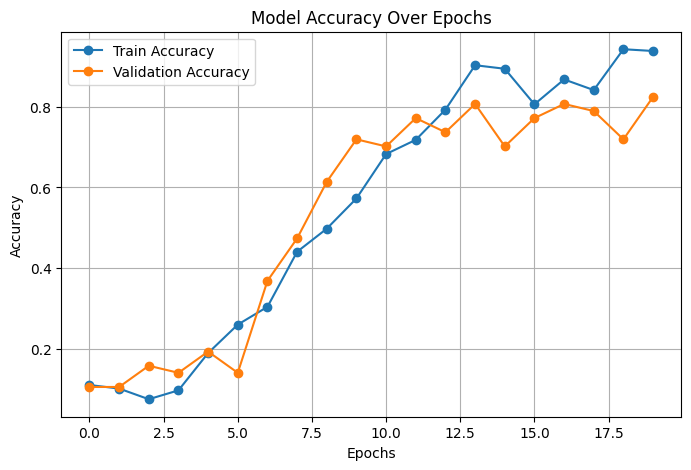

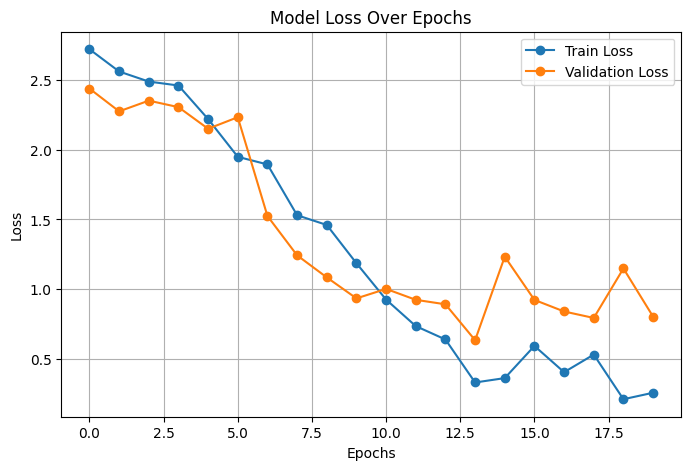

In [26]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [27]:
# Save only the weights
model.save_weights("video_transformer_model.weights.h5")


In [28]:
# Rebuild the same model architecture
model = build_transformer_learnable_pe(SEQ_LEN, X.shape[2], y.shape[1])

# Load saved weights
model.load_weights("video_transformer_model.weights.h5")
